In [2]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading our attrition processed data into a pandas dataframe
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

# Visualizing top 5 records
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Exploratory Data Analysis
#### 1. Where is attrition concentrated?
- Which job roles, departments, and job levels exceed the 16.1% baseline, and by enough to matter given their headcount?
- Is attrition an early-tenure phenomenon, a mid-career phenomenon, or both?

In [4]:
# Checking the overall attrition rate in the dataset
attrition_rate = (df["Attrition"] == "Yes").mean()
print(f"Overall attrition rate: {attrition_rate:.1%}")

Overall attrition rate: 16.1%


In [5]:
# Defining our attrition rate baseline
BASELINE = attrition_rate

In [18]:
# Creating a reusable attrition sumamry function for our analysis
def attrition_summary(df, column, baseline=BASELINE):
    summary = (
        df.groupby(column)
          .agg(
              Headcount=("EmployeeNumber", "size"),
              AttritionCount=("Attrition", lambda x: (x == "Yes").sum())
          )
    )

    # Calculate attrition rate as a percentage
    summary["AttritionRate"] = (
        summary["AttritionCount"] / summary["Headcount"] * 100
    )

    # Difference from company-wide baseline, in percentage points
    summary["DifferenceFromBaseline_pp"] = (
        summary["AttritionRate"] - (baseline * 100)
    )

    # How many times higher/lower than the baseline
    summary["RelativeToBaseline"] = (
        summary["AttritionRate"] / (baseline * 100)
    )

    return summary.sort_values(
        "AttritionRate",
        ascending=False
    )

In [ ]:
# Checking attrition summary by JobRole
job_role_summary = attrition_summary(df, "JobRole")

# Formating the dataframe values for better data analysis readability
job_role_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobRole,,,,,
Sales Representative,83,33,39.76%,+23.64 pp,2.47x
Laboratory Technician,259,62,23.94%,+7.82 pp,1.48x
Human Resources,52,12,23.08%,+6.95 pp,1.43x
Sales Executive,326,57,17.48%,+1.36 pp,1.08x
Research Scientist,292,47,16.10%,-0.03 pp,1.00x
Manufacturing Director,145,10,6.90%,-9.23 pp,0.43x
Healthcare Representative,131,9,6.87%,-9.25 pp,0.43x
Manager,102,5,4.90%,-11.22 pp,0.30x
Research Director,80,2,2.50%,-13.62 pp,0.16x


In [22]:
# Checking attrition summary by Department
department_summary = attrition_summary(df, "Department")

# Formating the dataframe values for better data analysis readability
department_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
Department,,,,,
Sales,446,92,20.63%,+4.51 pp,1.28x
Human Resources,63,12,19.05%,+2.93 pp,1.18x
Research & Development,961,133,13.84%,-2.28 pp,0.86x


In [23]:
# Checking attrition summary by JobLevel
job_level_summary = attrition_summary(df, "JobLevel")

# Formating the dataframe values for better data analysis readability
job_level_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobLevel,,,,,
1,543,143,26.34%,+10.21 pp,1.63x
3,218,32,14.68%,-1.44 pp,0.91x
2,534,52,9.74%,-6.38 pp,0.60x
5,69,5,7.25%,-8.88 pp,0.45x
4,106,5,4.72%,-11.41 pp,0.29x


- Which job roles, departments, and job levels exceed the 16.1% baseline, and by enough to matter given their headcount?

In [24]:
# To better analyse the organizational impact of the JobRole attrition rate, we'll add a new attribute for Excess attrition
# Through Excess attrition we can analyse how many more employees left than we would expect if this group had the company-wide baseline?
# Expected Attrition = Headcount*BASELINE
# Excess Attrition=Actual Attrition−Expected Attrition

job_role_summary["ExpectedAttrition"] = (
    job_role_summary["Headcount"] * BASELINE
).round(2)

job_role_summary["ExcessAttrition"] = (
    job_role_summary["AttritionRate"] -
    job_role_summary["ExpectedAttrition"]
).round(2)

job_role_summary.sort_values(
    "ExcessAttrition",
    ascending=False
)

job_role_summary.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
    "ExpectedAttrition": "{:,.0f}",
    "ExcessAttrition": "{:+,.0f}"
})

,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline,ExpectedAttrition,ExcessAttrition
JobRole,,,,,,,
Sales Representative,83,33,39.76%,+23.64 pp,2.47x,13,+26
Laboratory Technician,259,62,23.94%,+7.82 pp,1.48x,42,-18
Human Resources,52,12,23.08%,+6.95 pp,1.43x,8,+15
Sales Executive,326,57,17.48%,+1.36 pp,1.08x,53,-35
Research Scientist,292,47,16.10%,-0.03 pp,1.00x,47,-31
Manufacturing Director,145,10,6.90%,-9.23 pp,0.43x,23,-16
Healthcare Representative,131,9,6.87%,-9.25 pp,0.43x,21,-14
Manager,102,5,4.90%,-11.22 pp,0.30x,16,-12
Research Director,80,2,2.50%,-13.62 pp,0.16x,13,-10


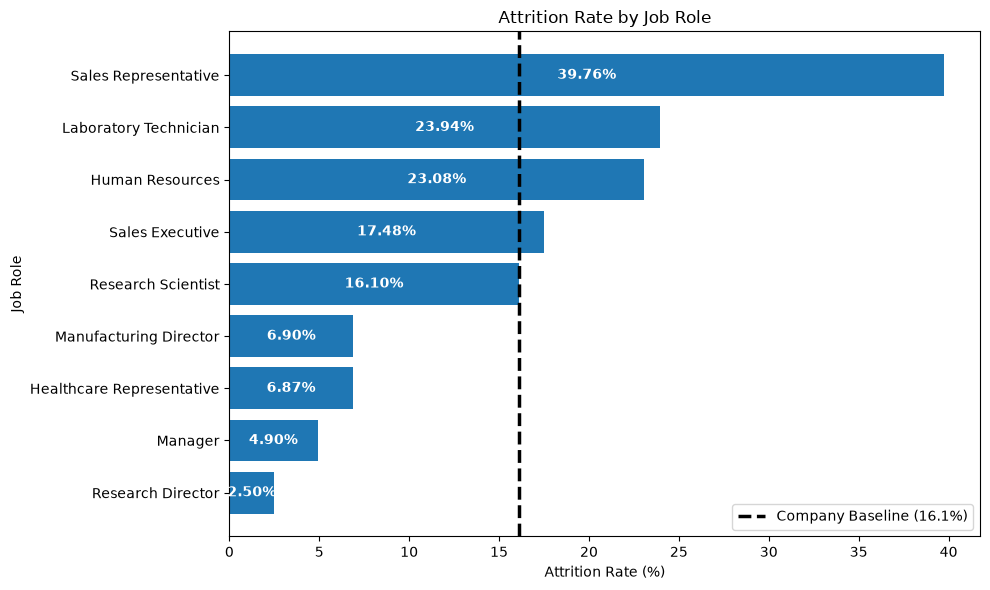

In [25]:
# Visualizing the JobRoles above the Attrition Rate Baseline (16.1%)
roles_above_baseline = (
    job_role_summary
    .sort_values("AttritionRate", ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    roles_above_baseline.index,
    roles_above_baseline["AttritionRate"]
)

# Add labels inside the bars
for bar, rate, headcount in zip(
    bars,
    roles_above_baseline["AttritionRate"],
    roles_above_baseline["Headcount"]
):
    plt.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        ha="center",
        va="center",
        fontweight="bold",
        color="white"
    )

# Company baseline
plt.axvline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.title("Attrition Rate by Job Role")

plt.legend()
plt.tight_layout()
plt.show()

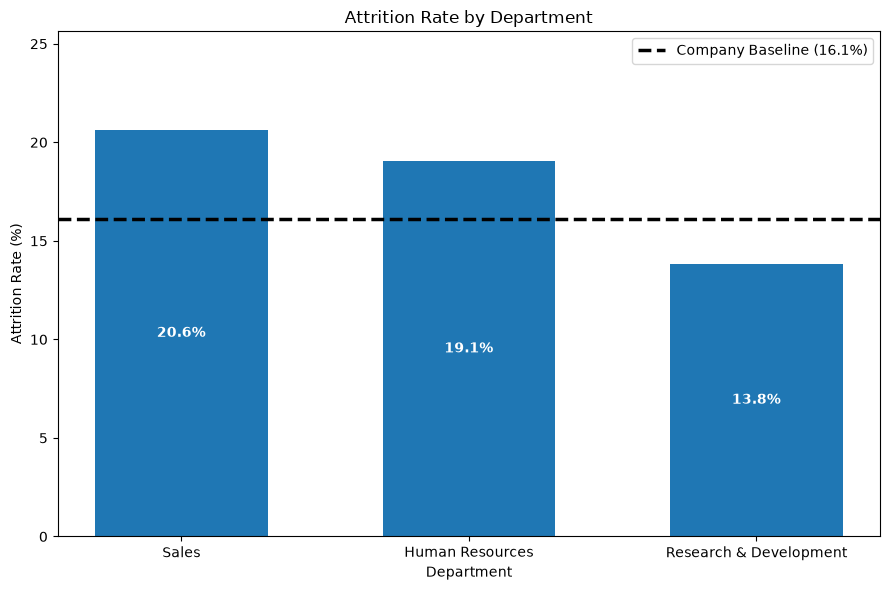

In [12]:
# Visualizing the Departments above the Attrition Rate Baseline (16.1%)
department_plot = department_summary.copy()

# Sort by attrition rate
department_plot = department_plot.sort_values(
    "AttritionRate",
    ascending=False
)

plt.figure(figsize=(9, 6))

# Bars
bars = plt.bar(
    department_plot.index,
    department_plot["AttritionRate"],
    width=0.6
)

# Company baseline
plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

# Labels inside bars
for bar, rate, headcount in zip(
    bars,
    department_plot["AttritionRate"],
    department_plot["Headcount"]
):
    if rate >= 8:
        # Place label inside the bar
        y = bar.get_height() / 2
        va = "center"
        text_color = "white"
    else:
        # Place label above very short bars
        y = bar.get_height() + 0.3
        va = "bottom"
        text_color = "black"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{rate:.1f}%",
        ha="center",
        va=va,
        fontweight="bold",
        color=text_color
    )

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.title("Attrition Rate by Department")

plt.ylim(
    0,
    department_plot["AttritionRate"].max() + 5
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Before visualizing JobLevel that exceeded the baseline rate we'll categorize them
job_level_labels = {
    1: "1 - Entry",
    2: "2 - Junior",
    3: "3 - Intermediate",
    4: "4 - Senior",
    5: "5 - Leadership"
}

# Create a copy for visualization
job_level_plot = job_level_summary.copy()

# Replace numeric index with descriptive labels
job_level_plot.index = job_level_plot.index.map(job_level_labels)

# Define the desired order
job_level_order = [
    "1 - Entry",
    "3 - Intermediate",
    "2 - Junior",    
    "5 - Leadership",
    "4 - Senior"
]

# Reorder the rows
job_level_plot = job_level_plot.reindex(job_level_order)

job_level_plot.style.format({
    "Headcount": "{:,.0f}",
    "AttritionCount": "{:,.0f}",
    "AttritionRate": "{:.2f}%",
    "DifferenceFromBaseline_pp": "{:+.2f} pp",
    "RelativeToBaseline": "{:.2f}x",
})


,Headcount,AttritionCount,AttritionRate,DifferenceFromBaseline_pp,RelativeToBaseline
JobLevel,,,,,
1 - Entry,543,143,26.34%,+10.21 pp,1.63x
3 - Intermediate,218,32,14.68%,-1.44 pp,0.91x
2 - Junior,534,52,9.74%,-6.38 pp,0.60x
5 - Leadership,69,5,7.25%,-8.88 pp,0.45x
4 - Senior,106,5,4.72%,-11.41 pp,0.29x


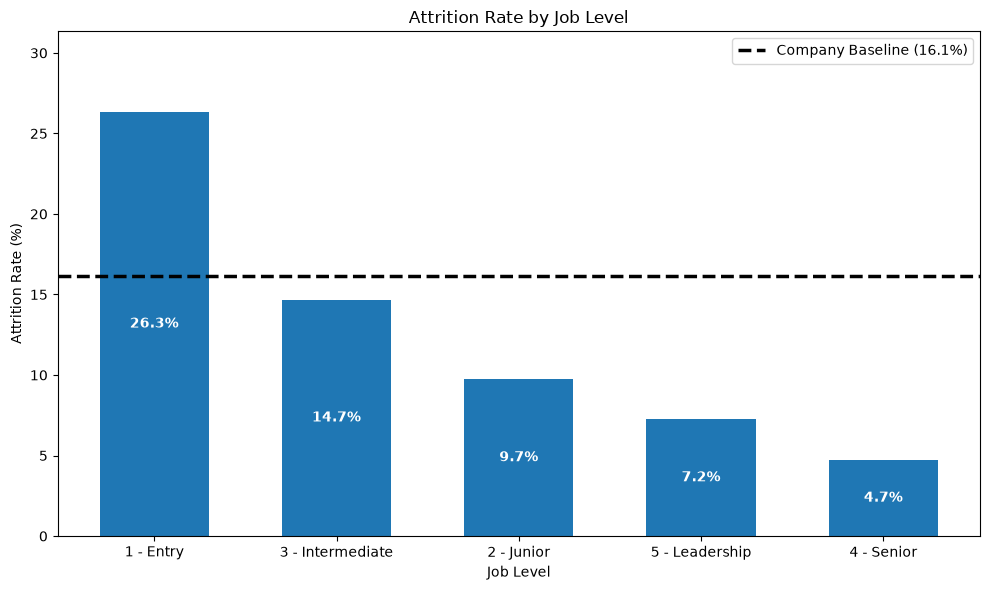

In [14]:
# Visualizing the JobLevel(s) above the Attrition Rate Baseline (16.1%)
plt.figure(figsize=(10, 6))

bars = plt.bar(
    job_level_plot.index,
    job_level_plot["AttritionRate"],
    width=0.6
)

# Company baseline
plt.axhline(
    BASELINE * 100,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Company Baseline ({BASELINE:.1%})"
)

# Labels inside bars
for bar, rate, headcount in zip(
    bars,
    job_level_plot["AttritionRate"],
    job_level_plot["Headcount"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{rate:.1f}%",
        ha="center",
        va="center",
        fontweight="bold",
        color="white"
    )

plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Level")

plt.ylim(
    0,
    max(job_level_plot["AttritionRate"]) + 5
)

plt.legend()
plt.tight_layout()
plt.show()